In [220]:
import warnings
warnings.filterwarnings('ignore')

In [221]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

In [222]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [223]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,219,Democrats
1,252,Democrats
2,214,Republicans
3,232,Democrats
4,234,Democrats
...,...,...
19995,202,Republicans
19996,268,Democrats
19997,209,Republicans
19998,238,Democrats


In [224]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,105,1,0.005,Republicans
1,143,1,0.005,Republicans
2,144,1,0.005,Republicans
3,148,1,0.005,Republicans
4,153,2,0.010,Republicans


In [225]:
np.unique(seat_sims['seats']).shape[0]

200

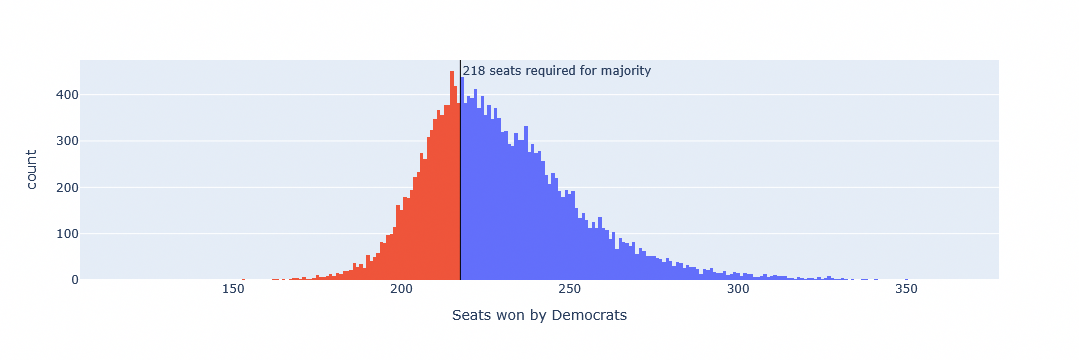

In [226]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner', 
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'})
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [227]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [228]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,...,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-4.471048,-3.116137,-7.390380,-4.541466,-1.750560,-9.768527,-0.722627,-5.943284,-3.694440,-5.359099,...,-4.249153,-4.291416,-4.534000,-4.406077,-4.206119,-8.427314,-3.200347,-7.548370,-0.859566,-0.165005
AL-01,-15.088355,-10.485246,-17.977657,-14.523089,-13.132176,-13.441290,-18.101140,-12.609494,-17.625891,-13.025307,...,-15.343176,-20.050927,-18.820599,-12.980799,-11.876105,-15.713282,-11.314792,-13.646970,-15.133705,-16.416269
AL-02,-4.086156,-1.217779,-2.764746,-4.456911,-0.087963,-5.788202,-1.671352,-4.907134,-6.711774,1.694385,...,-6.225040,-5.107635,-4.835136,-4.866557,-6.436336,-9.113795,2.008428,-7.193692,-1.512404,-3.282753
AL-03,-20.175550,-19.492711,-23.141723,-19.887764,-18.915981,-22.136931,-22.099544,-20.793248,-19.318470,-16.559846,...,-23.539780,-24.777715,-26.678474,-19.514530,-18.570744,-27.189771,-15.701482,-21.663642,-19.574860,-22.914574
AL-04,-32.047359,-26.609079,-35.171824,-36.903385,-26.325794,-34.662625,-29.953594,-31.466912,-27.136388,-30.426693,...,-34.238090,-33.924099,-34.130955,-30.615371,-29.804137,-37.972839,-28.034678,-32.138438,-30.175330,-30.834225


In [229]:
post.shape

(423, 20000)

In [230]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [231]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:31<00:00, 631.56it/s]


array(['NY-17', 'NY-03', 'WI-01', ..., 'OH-07', 'VA-02', 'NC-09'],
      shape=(20000,), dtype='<U32')

In [232]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-6.629379,-18.764506,-1,-37.529012,45.141913,3.721857,9.430,1,37.799511,52.452608
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-28.593056,-38.923019,0,-77.846039,35.880801,3.688031,0.005,2,28.677343,43.131274
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-6.762189,-19.716169,1,-39.432338,47.237149,3.583236,22.145,3,40.181652,54.249125
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-39.360957,-45.710827,-1,-91.421653,29.418174,3.602384,0.000,4,22.334939,36.522676
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-59.653053,-47.132870,-1,-94.265741,19.664136,3.625095,0.000,5,12.531445,26.813622


In [233]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-18.764506,-1,-37.529012,45.141913,3.721857,9.430,1,37.799511,52.452608,0.12
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-38.923019,0,-77.846039,35.880801,3.688031,0.005,2,28.677343,43.131274,0.00
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-19.716169,1,-39.432338,47.237149,3.583236,22.145,3,40.181652,54.249125,0.91
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-45.710827,-1,-91.421653,29.418174,3.602384,0.000,4,22.334939,36.522676,0.00
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-47.132870,-1,-94.265741,19.664136,3.625095,0.000,5,12.531445,26.813622,0.00


In [234]:
data.sort_values('tipping_point_prob', ascending=False).head(7)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
197,197,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",...,-3.195838,0,-6.391676,50.334015,3.704986,53.745,198,42.918042,57.642177,3.130
233,233,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,...,50.000000,0,100.000000,50.793916,3.750307,58.395,234,43.418292,58.130254,3.100
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",...,12.732090,-1,25.464181,50.288456,3.549274,53.495,38,43.289632,57.299945,2.715
191,191,MI-04,Sean McCann,Bill Huizenga,False,True,MI,4,"MCCANN, SEAN","HUIZENGA, WILLIAM P",...,7.674047,-1,15.348095,49.896064,3.533735,48.890,192,42.916752,56.864985,2.685
278,278,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",...,3.773526,-1,7.547052,50.529106,3.591512,55.945,279,43.497978,57.574295,2.640
319,319,PA-07,Bob Brooks,Ryan Mackenzie,False,True,PA,7,"BROOKS, BOB","MACKENZIE, RYAN EDWARD",...,6.533790,-1,13.067581,50.148067,3.639235,51.760,320,42.896050,57.260421,2.605
194,194,MI-07,William Lawrence,Tom Barrett,False,True,MI,7,"LAWRENCE, WILLIAM","BARRETT, THOMAS MORE",...,-25.887528,-1,-51.775056,49.818737,3.609815,48.110,195,42.721861,56.862147,2.570
